In [3]:
import pandas as pd

df = pd.read_csv("county_level_election.csv")
df.head()


,state,fipscode,county,population,hispanic,minority,female,unemployed,income,nodegree,bachelor,inactivity,obesity,density,cancer,votergap,trump,clinton
0,Colorado,8117,Summit County,27239,15.173,4.918,45.996,2.5,68352,5.4,48.1,8.1,13.1,46.0,46.2,-27.632,31.530,59.162
1,Colorado,8037,Eagle County,53653,30.040,5.169,47.231,3.1,76661,10.1,47.3,9.4,11.8,31.0,47.1,-19.897,36.058,55.955
2,Idaho,16067,Minidoka County,19226,34.070,5.611,49.318,3.7,46332,24.1,11.8,18.3,34.2,80.0,61.8,54.148,71.135,16.987
3,Colorado,8113,San Miguel County,7558,10.154,4.747,46.808,3.7,59603,4.7,54.4,12.4,16.7,5.7,62.6,-44.769,23.892,68.662
4,Utah,49051,Wasatch County,21600,13.244,4.125,48.812,3.4,65207,9.5,34.4,13.9,23.0,257.8,68.3,25.357,50.471,25.114


### Q1. What is the average votergap, assuming all counties are weighted equally?

To compute the unweighted average votergap across the nation, we take the simple mean of the `votergap` column across all counties. Each county contributes equally to the calculation.

The estimated unweighted average votergap is approximately **31.72 percentage points**, meaning that, on average, counties show a substantial advantage for Trump over Clinton.


In [5]:
avg_votergap_unweighted = df["votergap"].mean()
avg_votergap_unweighted


np.float64(31.723198303979125)

### Q2. What is the average votergap, assuming all states are weighted equally?

To weight all states equally, we first compute the mean `votergap` within each state. 
Then, we take the simple average of these state-level averages so that every state
contributes the same weight regardless of its population or number of counties.


In [6]:
# Q2: Average votergap with each state weighted equally

state_means = df.groupby("state")["votergap"].mean()
avg_state_weighted = state_means.mean()
avg_state_weighted


np.float64(20.815670013022892)

### Q3. Estimate the national overall votergap, assuming the entire population voted.

To estimate the national overall votergap, we treat each county’s vote share as if every resident voted. 
For each county, we convert the Trump and Clinton vote percentages into estimated vote counts by 
multiplying the percentage (divided by 100) by the county population. We then sum the estimated Trump votes 
and Clinton votes across all counties to obtain national totals. 

Using these totals, we compute the national Trump and Clinton vote shares and take their difference 
(Trump share minus Clinton share) as the national votergap.


In [7]:
# Q3: Population-weighted national votergap

# Estimated total Trump and Clinton votes
total_trump_votes = (df["trump"] / 100 * df["population"]).sum()
total_clinton_votes = (df["clinton"] / 100 * df["population"]).sum()

# National-level percentages
trump_pct_national = total_trump_votes / (total_trump_votes + total_clinton_votes) * 100
clinton_pct_national = total_clinton_votes / (total_trump_votes + total_clinton_votes) * 100

# National votergap
national_votergap = trump_pct_national - clinton_pct_national

national_votergap


np.float64(-2.931171327318104)

### Q4. What explains the difference between these quantities?

The three estimates differ because each one applies a different weighting scheme:

- **County-weighted average (Q1):** Every county contributes equally, regardless of its size. 
  Small rural counties have the same influence as large urban counties, which tends to produce a
  more pro-Trump result because many small counties lean Republican.

- **State-weighted average (Q2):** Each state contributes equally. This reduces the influence of
  large states with many urban areas and pulls the estimate closer to the political balance
  across states rather than people.

- **Population-weighted average (Q3):** Counties are weighted by population, so larger counties
  have more influence. Urban counties tend to lean Democratic, so the population-weighted estimate
  is more favorable to Clinton compared with the county-weighted or state-weighted averages.

Overall, the differences arise because population is distributed unevenly across counties and states,
and the political preferences of large and small counties differ systematically.


### Section 2 — Q1. Decision tree accuracy across different max depths

We split the data into an 80/20 training and testing set and fit decision tree
regressors with max depths ranging from 1 to 20. For each depth, we record the
training accuracy (R² on the training set) and the mean 10-fold cross-validation
accuracy to evaluate model generalization. We then plot both accuracy curves
against the number of nodes (max depth).


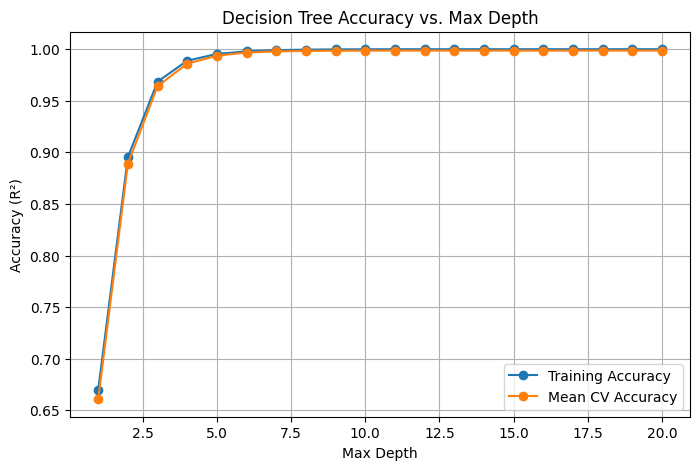

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Features (drop outcome + identifiers)
X = df.drop(columns=["votergap", "state", "county"])
y = df["votergap"]

# 80/20 split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

max_depths = range(1, 21)
train_scores = []
cv_scores = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, Y_train)

    # Training accuracy
    train_scores.append(model.score(X_train, Y_train))

    # 10-fold CV accuracy
    cv = cross_val_score(model, X_train, Y_train, cv=10)
    cv_scores.append(cv.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(max_depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(max_depths, cv_scores, marker="o", label="Mean CV Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy (R²)")
plt.title("Decision Tree Accuracy vs. Max Depth")
plt.legend()
plt.grid(True)
plt.show()


### Q2. Based on the plot, how many nodes would you recommend as the max depth?

From the plot, the mean cross-validation accuracy reaches its highest level around a
max depth of 4–6, and begins to level off or slightly decline afterward. This suggests
that deeper trees begin to overfit the training data. Therefore, a max depth of 
approximately **5** is recommended.


In [10]:
# Q2: Display training and CV accuracies for each depth

for depth, tr, cv in zip(max_depths, train_scores, cv_scores):
    print(f"Depth {depth:2d} | Train R² = {tr:.4f} | CV R² = {cv:.4f}")


Depth  1 | Train R² = 0.6698 | CV R² = 0.6607
Depth  2 | Train R² = 0.8954 | CV R² = 0.8889
Depth  3 | Train R² = 0.9685 | CV R² = 0.9642
Depth  4 | Train R² = 0.9889 | CV R² = 0.9860
Depth  5 | Train R² = 0.9954 | CV R² = 0.9937
Depth  6 | Train R² = 0.9979 | CV R² = 0.9968
Depth  7 | Train R² = 0.9991 | CV R² = 0.9979
Depth  8 | Train R² = 0.9996 | CV R² = 0.9984
Depth  9 | Train R² = 0.9998 | CV R² = 0.9985
Depth 10 | Train R² = 0.9999 | CV R² = 0.9986
Depth 11 | Train R² = 1.0000 | CV R² = 0.9987
Depth 12 | Train R² = 1.0000 | CV R² = 0.9987
Depth 13 | Train R² = 1.0000 | CV R² = 0.9986
Depth 14 | Train R² = 1.0000 | CV R² = 0.9986
Depth 15 | Train R² = 1.0000 | CV R² = 0.9986
Depth 16 | Train R² = 1.0000 | CV R² = 0.9986
Depth 17 | Train R² = 1.0000 | CV R² = 0.9986
Depth 18 | Train R² = 1.0000 | CV R² = 0.9987
Depth 19 | Train R² = 1.0000 | CV R² = 0.9987
Depth 20 | Train R² = 1.0000 | CV R² = 0.9987


### Q3. Why does the mean cross-validation accuracy begin to fall off at higher depths?

When the max depth becomes too large, the decision tree grows overly complex and 
begins to fit noise in the training data. This produces very high training accuracy 
but poorer performance on unseen data. This overfitting effect causes the mean 
cross-validation accuracy to decline at deeper tree depths.


In [11]:
# Q3: Demonstration of overfitting at high depth

shallow_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
deep_tree = DecisionTreeRegressor(max_depth=20, random_state=42)

shallow_tree.fit(X_train, Y_train)
deep_tree.fit(X_train, Y_train)

print("Shallow tree (depth=3):")
print(" Train R²:", shallow_tree.score(X_train, Y_train))
print(" Test  R²:", shallow_tree.score(X_test, Y_test))

print("\nDeep tree (depth=20):")
print(" Train R²:", deep_tree.score(X_train, Y_train))
print(" Test  R²:", deep_tree.score(X_test, Y_test))


Shallow tree (depth=3):
 Train R²: 0.9685316689384218
 Test  R²: 0.9657773021918117

Deep tree (depth=20):
 Train R²: 1.0
 Test  R²: 0.9981534911302978
